In [16]:
import pandas as pd
import logging
import sys
import os

# Log file path
log_file = r"C:\Users\davro\OneDrive\Desktop\git_project\log\data_pipeline.log"

# Logging configuration
logging.basicConfig(
    filename=log_file,
    filemode='a',
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"  
)

# Test logging
try:
    print('Processes started')
    logging.info('Logging setup completed!')
except Exception as e:
    logging.error(f"Xatolik bor, {log_file} ni tekshirib koring: {e}")


Processes started


In [22]:
sys.path.append(r"C:\Users\davro\OneDrive\Desktop\git_project\src")
path=r"C:\Users\davro\OneDrive\Desktop\git_project\Data\Raw_Data"

In [23]:
from data_loader import  DataLoader
loader=DataLoader(path)

In [24]:
try:
    full_df=loader.load_datasets()
    logging.info(f"Dataset yuklandi")
except Exception as e:
    logging.error(f"Xatolik bor")

In [25]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20926 entries, 0 to 20925
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            20926 non-null  int64  
 1   player_name   20926 non-null  object 
 2   games         20926 non-null  int64  
 3   time          20926 non-null  int64  
 4   goals         20926 non-null  int64  
 5   xG            20926 non-null  float64
 6   assists       20926 non-null  int64  
 7   xA            20926 non-null  float64
 8   shots         20926 non-null  int64  
 9   key_passes    20926 non-null  int64  
 10  yellow_cards  20926 non-null  int64  
 11  red_cards     20926 non-null  int64  
 12  position      20926 non-null  object 
 13  team_title    20926 non-null  object 
 14  npg           20926 non-null  int64  
 15  npxG          20926 non-null  float64
 16  xGChain       20926 non-null  float64
 17  xGBuildup     20926 non-null  float64
 18  league        20926 non-nu

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

In [27]:
sys.path.append(r"C:\Users\davro\OneDrive\Desktop\git_project\src")

In [28]:
from auto_pipeline import PlayerPerformanceModel
logging.info("Class import qilindi")

In [29]:
df=full_df

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20926 entries, 0 to 20925
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            20926 non-null  int64  
 1   player_name   20926 non-null  object 
 2   games         20926 non-null  int64  
 3   time          20926 non-null  int64  
 4   goals         20926 non-null  int64  
 5   xG            20926 non-null  float64
 6   assists       20926 non-null  int64  
 7   xA            20926 non-null  float64
 8   shots         20926 non-null  int64  
 9   key_passes    20926 non-null  int64  
 10  yellow_cards  20926 non-null  int64  
 11  red_cards     20926 non-null  int64  
 12  position      20926 non-null  object 
 13  team_title    20926 non-null  object 
 14  npg           20926 non-null  int64  
 15  npxG          20926 non-null  float64
 16  xGChain       20926 non-null  float64
 17  xGBuildup     20926 non-null  float64
 18  league        20926 non-nu

In [31]:
num_col=df.select_dtypes(include=['int64','float64']).columns.drop('xG').tolist()

In [33]:
cat_col=df.select_dtypes(include=['object']).columns.tolist()

In [34]:
player_model = PlayerPerformanceModel(num_col, cat_col, model=RandomForestRegressor())

In [36]:
from sklearn.model_selection import  train_test_split


In [37]:
x=df.drop('xG',axis=1)
y=df['xG']

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
player_model.fit(x_train,y_train)

In [41]:
y_pred=player_model.predict(x_test)

In [42]:
from sklearn.metrics import  r2_score,mean_squared_error

In [43]:
r2=r2_score(y_test,y_pred)

In [44]:
print(r2)

0.9828711279940795


# Error Analysis

In [45]:
# Absolute and Relative Errors
errors = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'abs_error': abs(y_test - y_pred),
    'error_percentage': abs(y_test - y_pred)/y_test*100
}).reset_index(drop=True)

print(errors)


         y_true     y_pred  abs_error  error_percentage
0      0.000000   0.000000   0.000000               NaN
1      0.147809   0.147738   0.000071          0.047729
2      0.407314   0.407303   0.000012          0.002850
3      0.095799   0.095970   0.000171          0.179010
4      0.459281   0.459354   0.000073          0.015889
...         ...        ...        ...               ...
4181   0.050196   0.050152   0.000043          0.086249
4182  10.844687   9.811423   1.033264          9.527835
4183   0.329428   0.329323   0.000105          0.031825
4184  13.411627  14.823151   1.411524         10.524631
4185   0.166261   0.166149   0.000112          0.067319

[4186 rows x 4 columns]


In [ ]:
#high
    # Outliers in the data

    # Missing important features

    # Model underfitting or overfitting

    # Data quality issues (mislabeled or noisy data)

In [ ]:
# low
#Model yaxshi

In [46]:
# Top 5 worst predictions
worst_errors = errors.sort_values(by='abs_error', ascending=False).head(5)
print(worst_errors)


         y_true     y_pred  abs_error  error_percentage
3162  35.589006  31.015148   4.573858         12.851884
2924  15.226494  11.201453   4.025041         26.434456
535   28.050517  24.200123   3.850394         13.726642
4151  21.232019  17.798933   3.433086         16.169381
1312   8.905443   5.532780   3.372663         37.871926


In [48]:
x_test.loc[worst_errors.index]


KeyError: "None of [Index([3162, 2924, 535, 4151, 1312], dtype='int64')] are in the [index]"

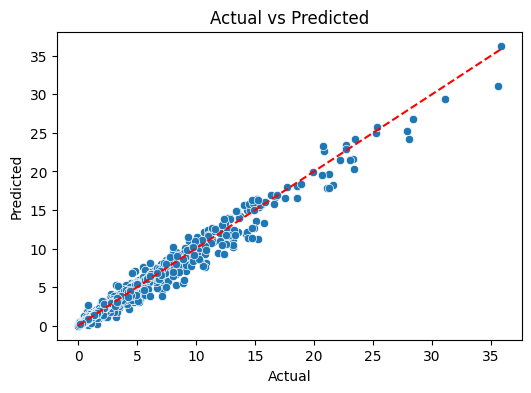

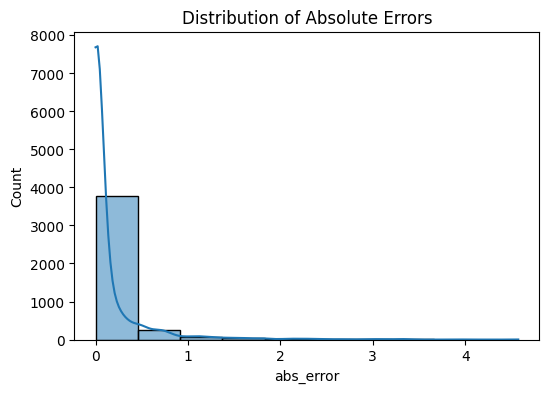

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# Error histogram
plt.figure(figsize=(6,4))
sns.histplot(errors['abs_error'], bins=10, kde=True)
plt.title('Distribution of Absolute Errors')
plt.show()


In [51]:
import plotly.express as px
scatter_fig = px.scatter(
    x=y_test, 
    y=y_pred, 
    labels={'x':'Actual', 'y':'Predicted'},
    title='Actual vs Predicted',
    hover_data={'x': y_test, 'y': y_pred}  # show values on hover
)

# Add diagonal line y=x
scatter_fig.add_shape(
    type="line",
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color="red", dash="dash")
)

scatter_fig.show()


In [52]:
hist_fig = px.histogram(
    errors, 
    x='abs_error', 
    nbins=30, 
    title='Distribution of Absolute Errors',
    labels={'abs_error':'Absolute Error'},
    marginal='box'  
)
hist_fig.show()

In [ ]:
#Nolga yaqinlari yaxshi model ekanligini isbotlaydi 